In [44]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import pickle


In [75]:
df = pd.read_csv("iris.csv")   
df.head()


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [46]:
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [47]:
df.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [48]:
X = df.drop("species", axis=1)
y = df["species"]
X
y

0         Iris-setosa
1         Iris-setosa
2         Iris-setosa
3         Iris-setosa
4         Iris-setosa
            ...      
145    Iris-virginica
146    Iris-virginica
147    Iris-virginica
148    Iris-virginica
149    Iris-virginica
Name: species, Length: 150, dtype: object

In [49]:
le = LabelEncoder()
y = le.fit_transform(y)
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [50]:
print("Encoded Classes:", list(le.classes_))

Encoded Classes: ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']


In [51]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42, stratify=y)

In [52]:
print("Training Data Shape:", X_train.shape)

Training Data Shape: (120, 4)


In [53]:
print("Testing Data Shape:", X_test.shape)

Testing Data Shape: (30, 4)


In [54]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [55]:
model = LogisticRegression(multi_class="multinomial", solver="lbfgs", max_iter=200)
model.fit(X_train_scaled, y_train)
print(" Logistic Regression Model Trained Successfully!")


 Logistic Regression Model Trained Successfully!


C:\Users\Tirupati\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [56]:
y_pred = model.predict(X_test_scaled)
print("Predictions on test data:", y_pred[:10])

Predictions on test data: [0 2 1 1 0 1 0 0 2 1]


In [57]:
acc = accuracy_score(y_test, y_pred)
print(" Accuracy in percentile:", acc*100)

 Accuracy in percentile: 93.33333333333333


In [58]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))


Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0.93      0.93      0.93        30



In [59]:
cm = confusion_matrix(y_test, y_pred)
print("\n🌀 Confusion Matrix:\n", cm)


🌀 Confusion Matrix:
 [[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]


C:\Users\Tirupati\AppData\Local\Temp\ipykernel_8624\142177227.py:15: UserWarning: Glyph 127800 (\N{CHERRY BLOSSOM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Tirupati\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127800 (\N{CHERRY BLOSSOM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


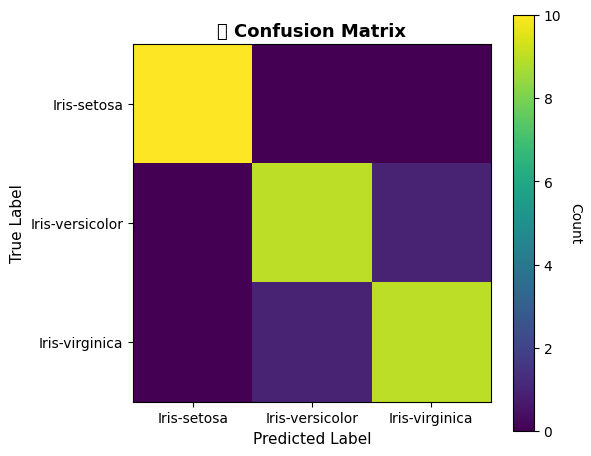

In [63]:
plt.figure(figsize=(6,5))
plt.imshow(cm, cmap="viridis")  # changed from 'Blues' → 'viridis' (modern green-blue tone)

plt.title("🌸 Confusion Matrix", fontsize=13, fontweight='bold')
plt.xlabel("Predicted Label", fontsize=11)
plt.ylabel("True Label", fontsize=11)

plt.xticks([0, 1, 2], le.classes_, fontsize=10)
plt.yticks([0, 1, 2], le.classes_, fontsize=10)

# Add colorbar with label
cbar = plt.colorbar()
cbar.set_label('Count', rotation=270, labelpad=15)

plt.tight_layout()
plt.show()

In [70]:
# Save model and scaler together
with open("logistic_model.pkl", "wb") as f:
    pickle.dump({"model": model, "scaler": scaler, "label_encoder": le}, f)

print("Model Saved as logistic_model.pkl")


Model Saved as logistic_model.pkl
